In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from collections import defaultdict
from PIL import Image
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

Image.MAX_IMAGE_PIXELS = None
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [4]:
from google.colab import files
files.upload()  # upload train and test CSVs

Saving test_dataset_splits.csv to test_dataset_splits.csv
Saving train_dataset_splits.csv to train_dataset_splits.csv


{'test_dataset_splits.csv': b',video_path,video_name,frame_0,frame_1,frame_2,frame_3,frame_4,frame_5,frame_6,frame_7,frame_8,frame_9,label,original_vid\n0,/content/FF_data/real/original_sequences/youtube/c40/images/596,596,0000.png,0020.png,0040.png,0060.png,0080.png,0100.png,0120.png,0140.png,0160.png,0180.png,0,596\n1,/content/FF_data/real/original_sequences/youtube/c40/images/596,596,0200.png,0220.png,0240.png,0260.png,0280.png,0300.png,0320.png,0340.png,0360.png,0380.png,0,596\n2,/content/FF_data/real/original_sequences/youtube/c40/images/616,616,0000.png,0020.png,0040.png,0060.png,0080.png,0100.png,0120.png,0140.png,0160.png,0180.png,0,616\n3,/content/FF_data/real/original_sequences/youtube/c40/images/616,616,0200.png,0220.png,0240.png,0260.png,0280.png,0300.png,0320.png,0340.png,0360.png,0380.png,0,616\n4,/content/FF_data/real/original_sequences/youtube/c40/images/616,616,0400.png,0420.png,0440.png,0460.png,0480.png,0500.png,0520.png,0540.png,0560.png,0580.png,0,616\n5,/content/F

In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/train_dataset_splits.csv')
test_df = pd.read_csv('/content/test_dataset_splits.csv')


print(f'Train clips: {len(train_df)}')
print(f'Test clips:  {len(test_df)}')


In [7]:
from torchvision import transforms
from sklearn.model_selection import train_test_split

class FrameDataset(Dataset):
    def __init__(self, df, res=224, transform=None):
        self.df        = df
        self.transform = transform or transforms.ToTensor()
        self.res       = res

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        """
        Returns a clip tensor of shape (3, T, H, W) = (3, 10, res, res).
        The DataLoader will stack these into (B, 3, T, H, W).
        """
        vidpath = self.df['video_path'].iloc[idx]
        tensors = []
        for i in range(10):
            fname = self.df[f'frame_{i}'].iloc[idx]
            path = os.path.join(vidpath, fname)
            img = Image.open(path).convert('RGB').resize((self.res, self.res))
            tensors.append(self.transform(img))  # (3, res, res)
        clip  = torch.stack(tensors, dim=1)      # (3, T, res, res)
        label = int(self.df['label'].iloc[idx])
        return clip, label


In [8]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


train_dataset = FrameDataset(train_df, res=224, transform=train_transform)
test_dataset = FrameDataset(test_df,  res=224, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=32)


print(f'Train samples: {len(train_dataset)}')
print(f'Test samples:  {len(test_dataset)}')

# check the shape
clips, labels = next(iter(train_loader))
print(f'Batch shape: {clips.shape}')
print(f'Labels: {labels[:8]}')

Train samples: 1579
Test samples:  426
Batch shape: torch.Size([32, 3, 10, 224, 224])
Labels: tensor([0, 1, 1, 1, 1, 1, 1, 0])


# Staged Training

In [9]:
class ResNetLSTM_FromBaseline(nn.Module):
    """
    ResNet-50 backbone loaded from pretrained baseline (frozen).
    LSTM trains on top of features.

    Input:  clips (B, 3, T, H, W)
    Output: logits (B, 2)
    """
    def __init__(self, hidden_size=256, num_layers=1, dropout=0.3, num_classes=2):
        super().__init__()

        # ResNet-50 backbone (frozen later)
        resnet = models.resnet50(weights=None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=2048,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, C, T, H, W = x.shape

        # Extract features from each frame using frozen ResNet
        frames = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
        feats = self.backbone(frames)          # (B*T, 2048, 7, 7)
        feats = self.avgpool(feats)            # (B*T, 2048, 1, 1)
        feats = feats.squeeze(-1).squeeze(-1)  # (B*T, 2048)
        feats = feats.reshape(B, T, -1)        # (B, T, 2048)

        # LSTM
        _, (h_n, _) = self.lstm(feats)

        # Classify
        out = self.dropout(h_n[-1])
        out = self.relu(out)
        return self.classifier(out)

In [11]:
# Create model
model = ResNetLSTM_FromBaseline(hidden_size=256, num_layers=1, dropout=0.3)

# Load baseline weights into backbone using reference ResNet
baseline_path = '/content/resnet50_baseline_scratch_epochs30.pth'
baseline_state = torch.load(baseline_path, map_location=device)

resnet_ref = models.resnet50(weights=None)
resnet_ref.fc = nn.Linear(resnet_ref.fc.in_features, 2)
resnet_ref.load_state_dict(baseline_state)

ref_backbone = nn.Sequential(*list(resnet_ref.children())[:-2])
model.backbone.load_state_dict(ref_backbone.state_dict())
print('Backbone weights loaded from baseline')

# Freeze backbone
for param in model.backbone.parameters():
    param.requires_grad = False
for param in model.avgpool.parameters():
    param.requires_grad = False
print('Backbone frozen')

# Move to device
model = model.to(device)

# Param summary
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f'Trainable parameters: {trainable:,}  (LSTM + classifier)')
print(f'Frozen parameters:    {frozen:,}  (ResNet backbone)')

# check shape
with torch.no_grad():
    test_clips = torch.randn(2, 3, 10, 224, 224).to(device)
    test_out   = model(test_clips)
    print(f'Output shape: {test_out.shape}')  # (2, 2)

Backbone weights loaded from baseline
Backbone frozen
Trainable parameters: 2,361,858  (LSTM + classifier)
Frozen parameters:    23,508,032  (ResNet backbone)
Output shape: torch.Size([2, 2])


In [13]:
from sklearn.utils.class_weight import compute_class_weight
import os

os.makedirs('/content/checkpoints', exist_ok=True)

# weight classes to account for imbalance
train_labels = train_dataset.df['label'].values
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.FloatTensor(weights).to(device)

# Only train LSTM and classifier
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=class_weights)
NUM_EPOCHS = 30

In [14]:
checkpoint_path = '/content/checkpoints/checkpoint_epoch_X.pt'

start_epoch = 0
train_losses = []
train_accs = []

# checkpoint to save progress
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    train_losses = checkpoint.get('train_losses', [])
    train_accs = checkpoint.get('train_accs', [])
    print(f'Resumed from checkpoint: epoch {checkpoint["epoch"]}')
else:
    print('No checkpoint found, training from scratch.')

# Training loop
for epoch in range(start_epoch, NUM_EPOCHS):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for clips, labels in train_loader:
        clips, labels = clips.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(clips)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Training Loss: {epoch_loss:.4f} | Trainng Acc: {epoch_acc:.4f}')

    if (epoch + 1) % 5 == 0:
        ckpt_save_path = f'/content/checkpoints/checkpoint_epoch_{epoch + 1}.pt'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'train_losses': train_losses,
            'train_accs': train_accs,
        }, ckpt_save_path)
        print(f'Saved checkpoint: {ckpt_save_path}')

print('\nTraining Done')

No checkpoint found, training from scratch.
Epoch 01/30 | Training Loss: 0.3921 | Trainng Acc: 0.8170
Epoch 02/30 | Training Loss: 0.3877 | Trainng Acc: 0.8151
Epoch 03/30 | Training Loss: 0.3802 | Trainng Acc: 0.8239
Epoch 04/30 | Training Loss: 0.3748 | Trainng Acc: 0.8214
Epoch 05/30 | Training Loss: 0.3763 | Trainng Acc: 0.8353
Saved checkpoint: /content/checkpoints/checkpoint_epoch_5.pt
Epoch 06/30 | Training Loss: 0.3622 | Trainng Acc: 0.8296
Epoch 07/30 | Training Loss: 0.3724 | Trainng Acc: 0.8252
Epoch 08/30 | Training Loss: 0.3664 | Trainng Acc: 0.8309
Epoch 09/30 | Training Loss: 0.3654 | Trainng Acc: 0.8163
Epoch 10/30 | Training Loss: 0.3775 | Trainng Acc: 0.8163
Saved checkpoint: /content/checkpoints/checkpoint_epoch_10.pt
Epoch 11/30 | Training Loss: 0.3868 | Trainng Acc: 0.8157
Epoch 12/30 | Training Loss: 0.3725 | Trainng Acc: 0.8227
Epoch 13/30 | Training Loss: 0.3745 | Trainng Acc: 0.8227
Epoch 14/30 | Training Loss: 0.3789 | Trainng Acc: 0.8214
Epoch 15/30 | Trainin

In [15]:
# saving training results
save_path = '/content/resnet50_lstm.pth'
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')

Model saved to /content/resnet50_lstm.pth


# Evaluation

In [16]:
model = ResNetLSTM_FromBaseline(hidden_size=256, num_layers=1)
model.load_state_dict(torch.load(save_path, map_location=device))
model = model.to(device)
model.eval()
print('Model loaded')

Model loaded


In [17]:
y_true = []
y_pred = []
misclassified_fakes = []

with torch.no_grad():
    for batch_idx, (clips, labels) in enumerate(test_loader):
        clips = clips.to(device)
        B = clips.shape[0]

        outputs = model(clips)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

        # Check for fake (1) predicted as real (0)
        for i in range(B):
            if labels[i].item() == 1 and preds[i] == 0:
                global_idx = batch_idx * test_loader.batch_size + i
                filepath = test_loader.dataset.df["video_path"].iloc[global_idx]
                misclassified_fakes.append(filepath)

print('=== ResNet-50 + LSTM RESULTS ===\n')
print(classification_report(
    y_true, y_pred,
    labels=[0, 1],
    target_names=['Real (0)', 'Fake (1)'],
    zero_division=0
))
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
print(f'\nF1 (weighted): {f1_score(y_true, y_pred, average="weighted", zero_division=0):.4f}')
print(f'F1 (macro):    {f1_score(y_true, y_pred, average="macro",    zero_division=0):.4f}')

# Write misclassified fakes to file
output_path = '/content/misclassified_fakes_lstm.txt'
with open(output_path, 'w') as f:
    f.write(f"Fake videos misclassified as Real ({len(misclassified_fakes)} total):\n\n")
    for filepath in misclassified_fakes:
        f.write(filepath + '\n')

print(f'\nMisclassified fakes written to {output_path} ({len(misclassified_fakes)} clips)')

=== ResNet-50 + LSTM RESULTS ===

              precision    recall  f1-score   support

    Real (0)       0.58      0.66      0.62       246
    Fake (1)       0.42      0.33      0.37       180

    accuracy                           0.52       426
   macro avg       0.50      0.50      0.49       426
weighted avg       0.51      0.52      0.51       426

Confusion Matrix:
[[163  83]
 [120  60]]

F1 (weighted): 0.5128
F1 (macro):    0.4939

Misclassified fakes written to /content/misclassified_fakes_lstm.txt (120 clips)


# Plot Training Curves

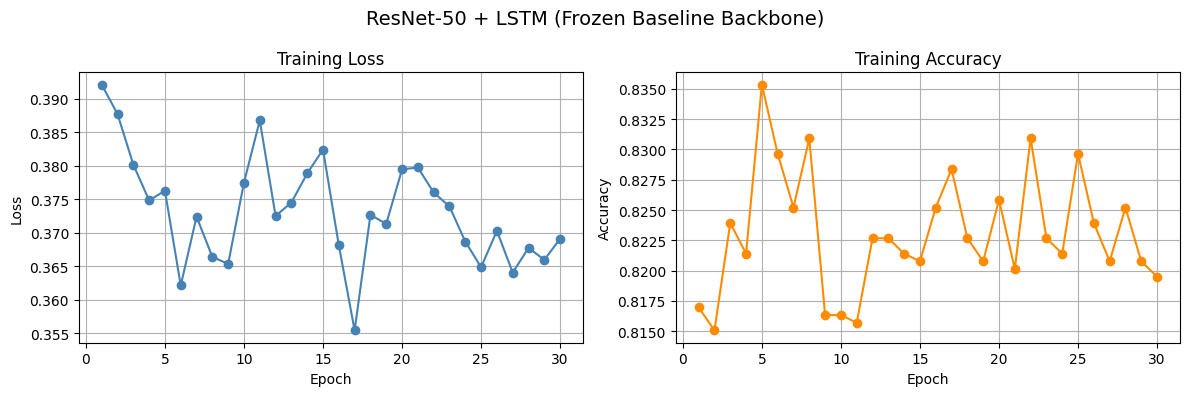

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(epochs, train_accs, marker='o', color='darkorange')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.suptitle('ResNet-50 + LSTM (Frozen Baseline Backbone)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/baseline_lstm_training_curves.png')
plt.show()